In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Read image directly as RGB
bgr = cv2.imread('Images/jupitermoon.jpeg')
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# Split into R, G, B planes
R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]

In [18]:
# Convert RGB to HSI manually
def rgb_to_hsi(rgb_img):
    rows, cols = rgb_img.shape[:2]
    H = np.zeros((rows, cols), dtype=np.float32)
    S = np.zeros((rows, cols), dtype=np.float32)
    I = np.zeros((rows, cols), dtype=np.float32)
    
    for i in range(rows):
        for j in range(cols):
            r = rgb_img[i, j, 0] / 255.0
            g = rgb_img[i, j, 1] / 255.0
            b = rgb_img[i, j, 2] / 255.0
            
            # Intensity
            I[i, j] = (r + g + b) / 3.0
            
            # Saturation
            min_val = min(r, g, b)
            if (r + g + b) == 0:
                S[i, j] = 0.0
            else:
                S[i, j] = 1.0 - (3.0 * min_val / (r + g + b))
            
            # Hue
            num = 0.5 * ((r - g) + (r - b))
            den = ((r - g)**2 + (r - b)*(g - b)) ** 0.5
            
            if den == 0:
                theta = 0.0
            else:
                cos_val = np.clip(num / den, -1, 1)
                theta = np.arccos(cos_val)
            
            if b <= g:
                h = theta
            else:
                h = 2 * np.pi - theta
            
            H[i, j] = h / (2 * np.pi)
    
    return H, S, I

# Convert
H, S, I = rgb_to_hsi(rgb)

# Normalize for display
H_norm = (H * 255).astype(np.uint8)
S_norm = (S * 255).astype(np.uint8)
I_norm = (I * 255).astype(np.uint8)

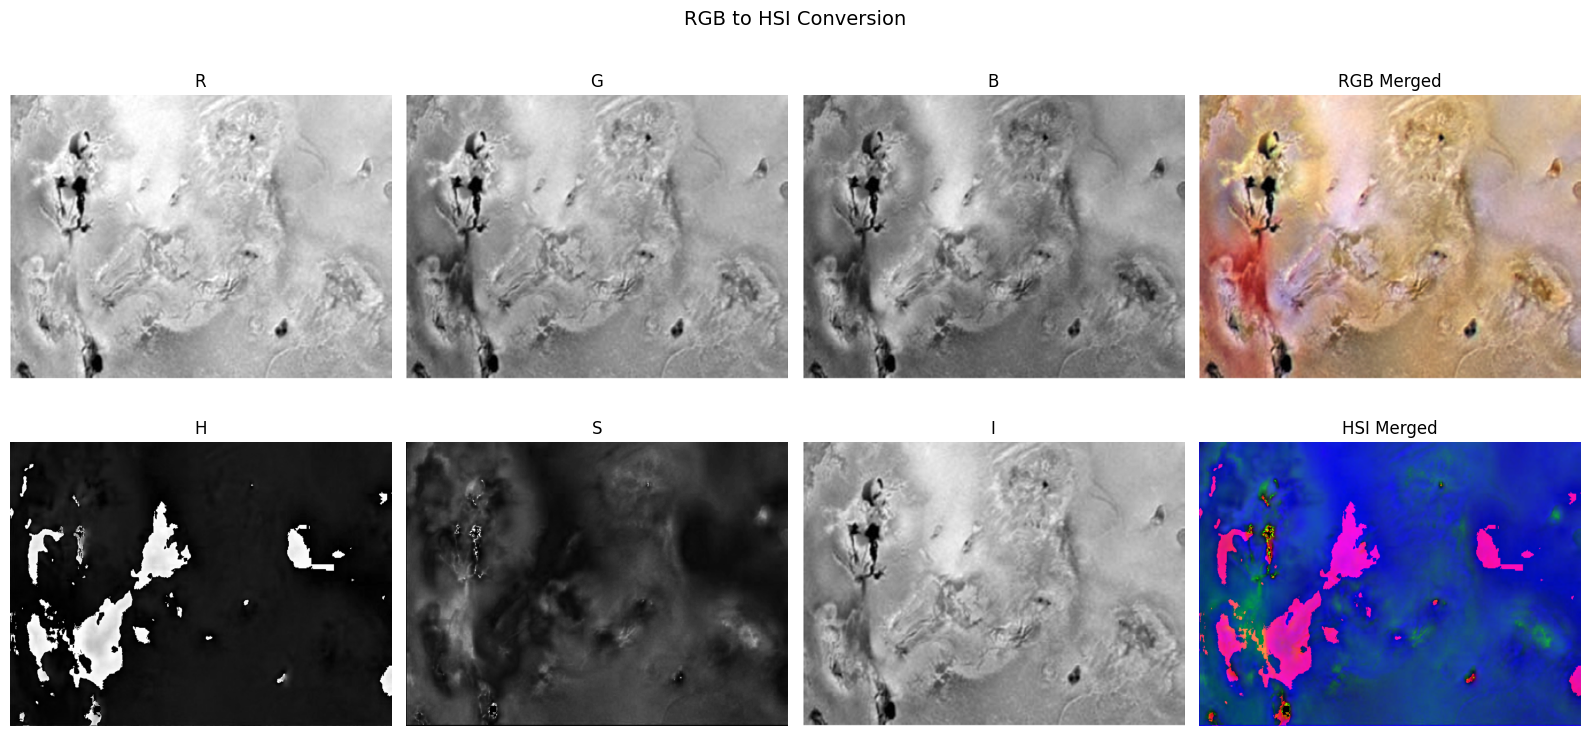

In [19]:
# Display individual planes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('RGB to HSI Conversion', fontsize=14)

# Input RGB planes
axes[0, 0].imshow(R, cmap='gray')
axes[0, 0].set_title('R')
axes[0, 0].axis('off')

axes[0, 1].imshow(G, cmap='gray')
axes[0, 1].set_title('G')
axes[0, 1].axis('off')

axes[0, 2].imshow(B, cmap='gray')
axes[0, 2].set_title('B')
axes[0, 2].axis('off')

# Merged RGB
axes[0, 3].imshow(rgb)
axes[0, 3].set_title('RGB Merged')
axes[0, 3].axis('off')

# Output HSI planes
axes[1, 0].imshow(H_norm, cmap='gray')
axes[1, 0].set_title('H')
axes[1, 0].axis('off')

axes[1, 1].imshow(S_norm, cmap='gray')
axes[1, 1].set_title('S')
axes[1, 1].axis('off')

axes[1, 2].imshow(I_norm, cmap='gray')
axes[1, 2].set_title('I')
axes[1, 2].axis('off')

# Merged HSI
hsi_merged = np.dstack((H_norm, S_norm, I_norm))
axes[1, 3].imshow(hsi_merged)
axes[1, 3].set_title('HSI Merged')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Apply 3x3 Gaussian filter manually
def gaussian_filter(plane):
    kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0
    rows, cols = plane.shape
    output = np.zeros_like(plane, dtype=np.float32)
    
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            region = plane[i-1:i+2, j-1:j+2].astype(np.float32)
            output[i, j] = np.sum(region * kernel)
    
    return output

# Read noisy image and convert to RGB/HSI
noisy_bgr = cv2.imread('images/jupitermoonnoise.jpeg')
noisy_rgb = cv2.cvtColor(noisy_bgr, cv2.COLOR_BGR2RGB)

# Split RGB planes
R_n = noisy_rgb[:, :, 0].astype(np.float32)
G_n = noisy_rgb[:, :, 1].astype(np.float32)
B_n = noisy_rgb[:, :, 2].astype(np.float32)

# Filter RGB planes
R_filt = gaussian_filter(R_n)
G_filt = gaussian_filter(G_n)
B_filt = gaussian_filter(B_n)

# Convert noisy RGB to HSI
H_n, S_n, I_n = rgb_to_hsi(noisy_rgb)

# Filter HSI planes
H_filt = gaussian_filter(H_n)
S_filt = gaussian_filter(S_n)
I_filt = gaussian_filter(I_n)

# Normalize for display
R_n_disp = np.clip(R_n, 0, 255).astype(np.uint8)
G_n_disp = np.clip(G_n, 0, 255).astype(np.uint8)
B_n_disp = np.clip(B_n, 0, 255).astype(np.uint8)

R_filt_disp = np.clip(R_filt, 0, 255).astype(np.uint8)
G_filt_disp = np.clip(G_filt, 0, 255).astype(np.uint8)
B_filt_disp = np.clip(B_filt, 0, 255).astype(np.uint8)

H_n_disp = (H_n * 255).astype(np.uint8)
S_n_disp = (S_n * 255).astype(np.uint8)
I_n_disp = (I_n * 255).astype(np.uint8)

H_filt_disp = (H_filt * 255).astype(np.uint8)
S_filt_disp = (S_filt * 255).astype(np.uint8)
I_filt_disp = (I_filt * 255).astype(np.uint8)

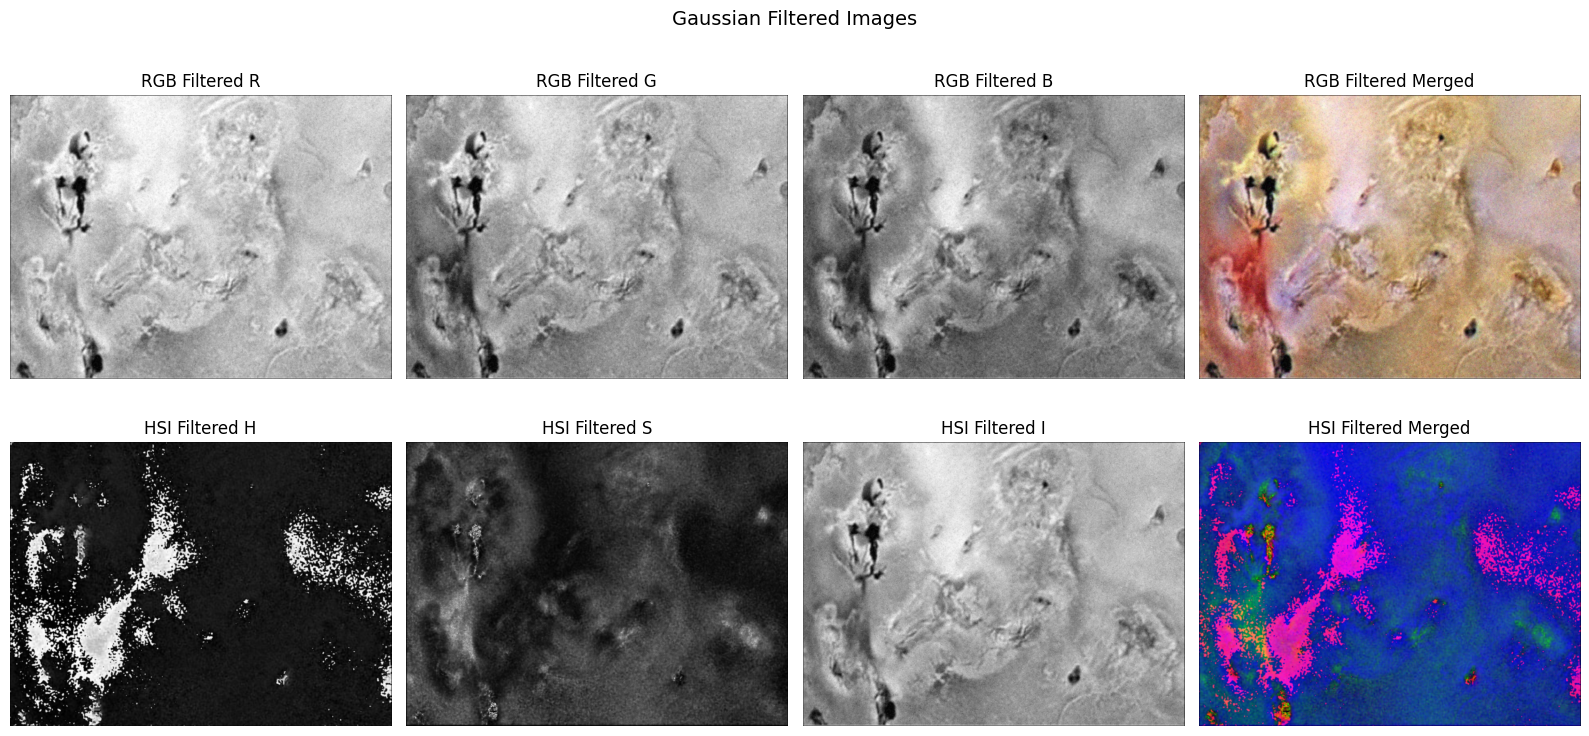

In [21]:
# Display filtered results only
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Gaussian Filtered Images', fontsize=14)

# Row 1: RGB filtered planes
axes[0, 0].imshow(R_filt_disp, cmap='gray')
axes[0, 0].set_title('RGB Filtered R')
axes[0, 0].axis('off')

axes[0, 1].imshow(G_filt_disp, cmap='gray')
axes[0, 1].set_title('RGB Filtered G')
axes[0, 1].axis('off')

axes[0, 2].imshow(B_filt_disp, cmap='gray')
axes[0, 2].set_title('RGB Filtered B')
axes[0, 2].axis('off')

rgb_filt_merged = np.dstack((R_filt_disp, G_filt_disp, B_filt_disp))
axes[0, 3].imshow(rgb_filt_merged)
axes[0, 3].set_title('RGB Filtered Merged')
axes[0, 3].axis('off')

# Row 2: HSI filtered planes
axes[1, 0].imshow(H_filt_disp, cmap='gray')
axes[1, 0].set_title('HSI Filtered H')
axes[1, 0].axis('off')

axes[1, 1].imshow(S_filt_disp, cmap='gray')
axes[1, 1].set_title('HSI Filtered S')
axes[1, 1].axis('off')

axes[1, 2].imshow(I_filt_disp, cmap='gray')
axes[1, 2].set_title('HSI Filtered I')
axes[1, 2].axis('off')

hsi_filt_merged = np.dstack((H_filt_disp, S_filt_disp, I_filt_disp))
axes[1, 3].imshow(hsi_filt_merged)
axes[1, 3].set_title('HSI Filtered Merged')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()